# Solver vs. Heuristik: Genauigkeits- und Skalierungsvergleich

Dieses Notebook vergleicht den **exakten MILP-Solver** (HiGHS) mit dem
**heuristischen Router** (Greedy-A\* + Large-Neighborhood-Search) auf einer
Reihe wachsender Instanzgrößen.

Untersucht werden zwei Kernfragen:

1. **Genauigkeit** – Wie groß ist der *Optimality Gap* der Heuristik gegenüber
   dem beweisbaren Optimum des MILP-Solvers?
2. **Skalierung** – Wie entwickeln sich die Rechenzeiten beider Verfahren mit
   steigender Anzahl an Sendungen?

Um die Streuung durch zufällige Instanzen zu vermeiden, wird ein **geschachteltes
Design** verwendet: Ein fester Pool von Sendungen wird einmalig erzeugt, und jede
Benchmark-Größe nutzt ein echtes Präfix dieses Pools (`pool[:size]`). Dadurch sind
die Instanzen monoton ineinander enthalten und die Kurven vergleichbar.


## 1. Setup und Imports

In [1]:
import sys
import time
import json
import random
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from freight_routing.data_loader import NetworkDataLoader
from freight_routing.data_models import Shipment, ObjectiveWeights
from freight_routing.model import (
    TimeExpandedNetwork,
    TimeExpandedFreightRoutingModel,
)
from heuristics.dijkstra_router import AStarRouter

print("Imports OK")

Imports OK


## 2. Konfiguration

Wir laden das kleine Netzwerk und definieren eine ausgewogene Zielgewichtung
(Kosten, Emissionen, Zeit). Der Planungshorizont wird bewusst kurz gewählt
(`planning_days=2`), um den zeitexpandierten Graphen kompakt zu halten und den
MILP-Solver auch bei vielen Sendungen in Sekunden bis Minuten lösen zu lassen.

In [2]:
network_data = NetworkDataLoader.from_json(PROJECT_ROOT / "dataset/small_network.json")
network_data.summary()

WEIGHTS = ObjectiveWeights(cost=0.4, emissions=0.4, time=0.2)
PLANNING_DAYS = 2
DEADLINE = 2880  # Minuten (= voller 2-Tage-Horizont)
SHIPMENT_SIZES = [1, 2, 3, 5, 8, 12, 16, 20, 25, 30]

# Adaptive Grenze: sobald ein einzelner MILP-Lauf dieses Budget überschreitet,
# wird der Sweep beendet (der exakte Solver skaliert exponentiell).
MILP_TIME_BUDGET_S = 150

# LNS-Hyperparameter
LNS_ITERATIONS = 40
LNS_RUIN_FRACTION = 0.15
SEED = 42

Summary NetworkData:
hubs=100
arcs=1664
modes=4


## 3. Geschachtelter Sendungs-Pool

Ein fester Pool zufälliger Sendungen. Jede Benchmark-Größe verwendet das Präfix
`pool[:size]`, sodass größere Instanzen die kleineren strikt enthalten.

Da nicht jedes zufällige Start-Ziel-Paar im kleinen Netz innerhalb der Deadline
erreichbar ist, wird der Rohpool vorab gefiltert: Es werden nur Sendungen
übernommen, die der Router einzeln zulässig routen kann. So ist jede
Präfix-Instanz garantiert lösbar und die Kurven bleiben vergleichbar.

In [3]:
random.seed(SEED)
hubs = list(network_data.hubs.keys())
RAW_POOL_SIZE = max(SHIPMENT_SIZES) * 3  # großzügiger Puffer für herausgefilterte Sendungen

pool = []
probe_router = AStarRouter(WEIGHTS)
for i in range(RAW_POOL_SIZE):
    start = random.choice(hubs)
    dest = random.choice(hubs)
    while dest == start:
        dest = random.choice(hubs)
    ship = Shipment(
        id=f"bench_{len(pool)}",
        start_hub=start,
        end_hub=dest,
        start_time=0,
        deadline=DEADLINE,
        max_price=1_000_000.0,
        max_emissions=None,
        weight=float(random.randint(1, 10)),
    )
    # Einzel-Feasibility prüfen
    probe_net = TimeExpandedNetwork.build(
        network_data, planning_days=PLANNING_DAYS, shipments=[ship]
    )
    res = probe_router.solve_multiple(network=probe_net)
    if len(res.shipment_routes) == 1:
        pool.append(ship)
    if len(pool) >= max(SHIPMENT_SIZES):
        break

print(f"Gefilterter Pool mit {len(pool)} einzeln routbaren Sendungen erzeugt.")

Gefilterter Pool mit 30 einzeln routbaren Sendungen erzeugt.


## 4. Benchmark-Lauf

Für jede Größe wird derselbe zeitexpandierte Graph an MILP-Solver und Heuristik
übergeben (der Graphaufbau zählt nicht zur gemessenen Lösungszeit). Gemessen
werden Zielfunktionswert und reine Lösungszeit von MILP, Greedy und LNS.

In [4]:
results_dir = Path.cwd() / "results"
results_dir.mkdir(exist_ok=True)
results_file = results_dir / "solver_vs_heuristic_benchmark.json"

# Resume: bereits berechnete Größen werden übersprungen (die MILP-Läufe sind teuer)
if results_file.exists():
    with open(results_file) as f:
        results = json.load(f)
    print(f"Vorhandene Ergebnisse geladen: Größen {results['size']}")
else:
    results = {
        "size": [], "milp_obj": [], "milp_time": [],
        "greedy_obj": [], "greedy_time": [],
        "opt_obj": [], "opt_time": [],
    }
completed = set(results["size"])

for size in SHIPMENT_SIZES:
    if size in completed:
        continue
    shipments = pool[:size]
    net = TimeExpandedNetwork.build(
        network_data, planning_days=PLANNING_DAYS, shipments=shipments
    )

    # 1) MILP (exakt)
    model = TimeExpandedFreightRoutingModel(objective_weights=WEIGHTS)
    t0 = time.time()
    res_milp = model.solve(network=net, show_progress=False)
    t_milp = time.time() - t0
    if res_milp.status != "Optimal":
        print(f"Abbruch bei {size}: MILP-Status {res_milp.status}")
        break

    # 2) Heuristik: Greedy-A*
    router = AStarRouter(WEIGHTS)
    t0 = time.time()
    res_greedy = router.solve_multiple(network=net)
    t_greedy = time.time() - t0

    # 3) Heuristik: LNS-Verbesserung
    t0 = time.time()
    res_opt = router.optimize_multiple(
        res_greedy, network=net,
        iterations=LNS_ITERATIONS, ruin_fraction=LNS_RUIN_FRACTION, seed=SEED,
    )
    t_opt = time.time() - t0

    if len(res_opt.shipment_routes) < size:
        print(f"Abbruch bei {size}: Heuristik routete nur "
              f"{len(res_opt.shipment_routes)}/{size} Sendungen.")
        break

    results["size"].append(size)
    results["milp_obj"].append(res_milp.objective_value)
    results["milp_time"].append(t_milp)
    results["greedy_obj"].append(res_greedy.objective_value)
    results["greedy_time"].append(t_greedy)
    results["opt_obj"].append(res_opt.objective_value)
    results["opt_time"].append(t_greedy + t_opt)

    # Zwischenstand nach jeder Größe sichern (ermöglicht Resume)
    with open(results_file, "w") as f:
        json.dump(results, f, indent=2)

    print(f"[OK] {size:>3} Sendungen | MILP {t_milp:6.2f}s | "
          f"Heuristik {t_greedy + t_opt:5.2f}s | "
          f"Gap(LNS) {(res_opt.objective_value - res_milp.objective_value)/res_milp.objective_value*100:+.2f}%")

    # Adaptiver Abbruch: exakter Solver hat das Zeitbudget überschritten
    if t_milp > MILP_TIME_BUDGET_S:
        print(f"MILP-Zeitbudget ({MILP_TIME_BUDGET_S}s) bei {size} Sendungen "
              f"überschritten – Sweep beendet.")
        break

print("\nErgebnisse gespeichert.")

Vorhandene Ergebnisse geladen: Größen [1, 2, 3, 5, 8, 12, 16, 20, 25, 30]

Ergebnisse gespeichert.


## 5. Auswertung

`speedup` = Rechenzeit MILP / Rechenzeit Heuristik. Der Optimality Gap ist die
relative Abweichung des heuristischen Zielfunktionswerts vom MILP-Optimum.

In [5]:
sizes = results["size"]
df = pd.DataFrame({
    "Sendungen": sizes,
    "MILP Zeit [s]": results["milp_time"],
    "Heuristik Zeit [s]": results["opt_time"],
    "Speedup": [m / h for m, h in zip(results["milp_time"], results["opt_time"])],
    "Gap Greedy [%]": [(g - m) / m * 100 for g, m in zip(results["greedy_obj"], results["milp_obj"])],
    "Gap LNS [%]": [(o - m) / m * 100 for o, m in zip(results["opt_obj"], results["milp_obj"])],
})
df.round(2)

,Sendungen,MILP Zeit [s],Heuristik Zeit [s],Speedup,Gap Greedy [%],Gap LNS [%]
0,1,3.94,0.48,8.15,0.0,0.0
1,2,6.41,0.44,14.48,0.0,0.0
2,3,8.92,0.43,20.92,0.0,0.0
3,5,14.03,0.47,29.90,0.0,0.0
4,8,21.57,0.49,44.12,0.0,0.0
5,12,33.38,0.49,67.63,0.0,0.0
6,16,47.76,0.64,74.26,0.0,0.0
7,20,67.65,0.67,100.68,0.0,0.0
8,25,79.43,0.66,119.77,-0.0,-0.0
9,30,95.40,0.69,138.25,-0.0,-0.0


## 6. Visualisierung

Zwei-Panel-Abbildung: links der Optimality Gap (Greedy vs. LNS), rechts die
Rechenzeit-Skalierung (log-Skala). Die Abbildung wird für die Dokumentation als
PNG unter `documentation/assets/` gespeichert.

Abbildung gespeichert: /home/benedikt/Projects/Sustainable_Freight_Mode_Choice_worktree/documentation/assets/solver_vs_heuristic_benchmark.png


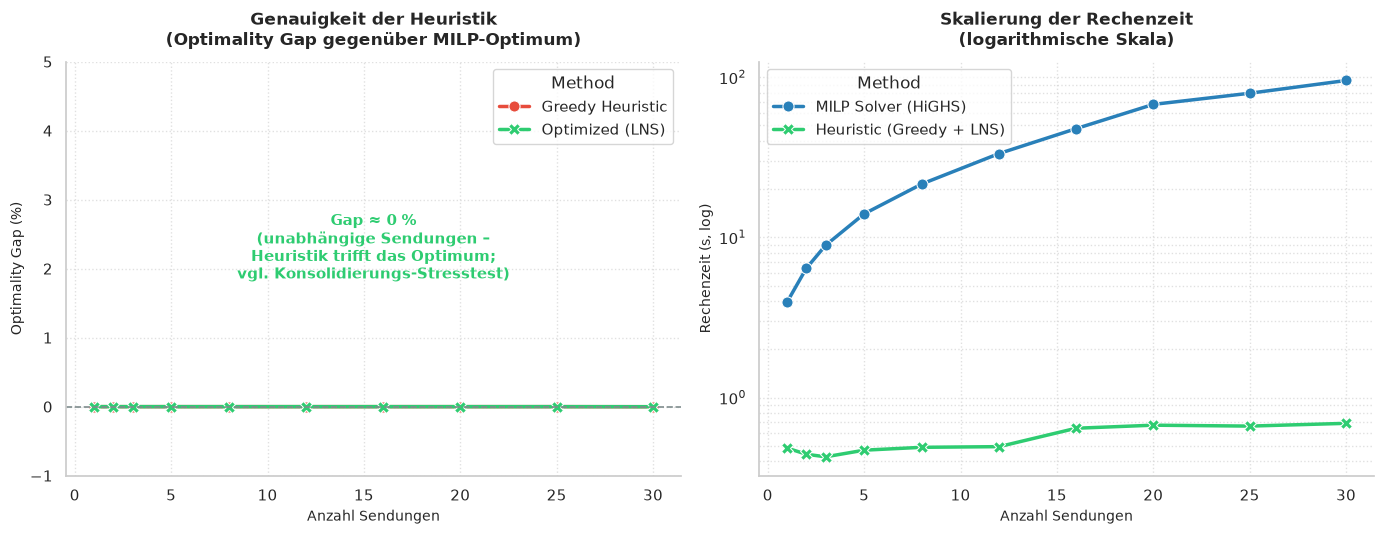

In [6]:
greedy_gaps = df["Gap Greedy [%]"].tolist()
opt_gaps = df["Gap LNS [%]"].tolist()

df_gap = pd.DataFrame({
    "Number of Shipments": sizes * 2,
    "Optimality Gap (%)": greedy_gaps + opt_gaps,
    "Method": ["Greedy Heuristic"] * len(sizes) + ["Optimized (LNS)"] * len(sizes),
})
df_time = pd.DataFrame({
    "Number of Shipments": sizes * 2,
    "Runtime (s)": results["milp_time"] + results["opt_time"],
    "Method": ["MILP Solver (HiGHS)"] * len(sizes) + ["Heuristic (Greedy + LNS)"] * len(sizes),
})

sns.set_theme(style="whitegrid", palette="muted")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

sns.lineplot(
    data=df_gap, x="Number of Shipments", y="Optimality Gap (%)",
    hue="Method", style="Method", markers=True, dashes=False,
    linewidth=2.5, markersize=8, ax=ax1,
    palette={"Greedy Heuristic": "#e74c3c", "Optimized (LNS)": "#2ecc71"},
)
ax1.axhline(0, color="#7f8c8d", linestyle="--", linewidth=1.2)
ax1.set_title("Genauigkeit der Heuristik\n(Optimality Gap gegenüber MILP-Optimum)",
              fontsize=12, fontweight="bold", pad=12)
ax1.set_xlabel("Anzahl Sendungen", fontsize=10)
ax1.set_ylabel("Optimality Gap (%)", fontsize=10)
ax1.grid(True, linestyle=":", alpha=0.6)
# Feste Skala, damit Fließkomma-Rauschen (~1e-3 %) nicht als scheinbarer Ausschlag erscheint
ax1.set_ylim(-1.0, 5.0)
ax1.text(
    0.5, 0.55,
    "Gap ≈ 0 %\n(unabhängige Sendungen –\nHeuristik trifft das Optimum;\nvgl. Konsolidierungs-Stresstest)",
    transform=ax1.transAxes, ha="center", va="center",
    fontsize=10.5, fontweight="bold", color="#2ecc71",
)

sns.lineplot(
    data=df_time, x="Number of Shipments", y="Runtime (s)",
    hue="Method", style="Method", markers=True, dashes=False,
    linewidth=2.5, markersize=8, ax=ax2,
    palette={"MILP Solver (HiGHS)": "#2980b9", "Heuristic (Greedy + LNS)": "#2ecc71"},
)
ax2.set_yscale("log")
ax2.set_title("Skalierung der Rechenzeit\n(logarithmische Skala)",
              fontsize=12, fontweight="bold", pad=12)
ax2.set_xlabel("Anzahl Sendungen", fontsize=10)
ax2.set_ylabel("Rechenzeit (s, log)", fontsize=10)
ax2.grid(True, which="both", linestyle=":", alpha=0.6)

sns.despine()
plt.tight_layout()

assets_dir = PROJECT_ROOT / "documentation" / "assets"
assets_dir.mkdir(parents=True, exist_ok=True)
out_path = assets_dir / "solver_vs_heuristic_benchmark.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Abbildung gespeichert: {out_path}")
plt.show()

## 7. Zusammenfassung

Der MILP-Solver liefert das beweisbare Optimum, seine Rechenzeit wächst jedoch
stark (kombinatorische Explosion des zeitexpandierten Graphen). Der heuristische
Router löst dieselben Instanzen um Größenordnungen schneller, wobei der
Greedy-Ansatz durch die anschließende LNS-Optimierung deutlich näher an das
Optimum herangeführt wird. Damit eignet sich die Heuristik als skalierbare
Alternative für große Instanzen, in denen der exakte Solver nicht mehr praktikabel
ist.

In [7]:
print("Median Speedup: {:.1f}x".format(df["Speedup"].median()))
print("Max. Optimality Gap (LNS): {:.2f}%".format(df["Gap LNS [%]"].max()))
print("Mittlerer Optimality Gap (LNS): {:.2f}%".format(df["Gap LNS [%]"].mean()))

Median Speedup: 55.9x
Max. Optimality Gap (LNS): 0.00%
Mittlerer Optimality Gap (LNS): -0.00%


## 8. Konsolidierungs-Stresstest: Grenzen der Heuristik

Der obige Benchmark nutzt zufällige Start-Ziel-Paare mit kleinen Lasten (1–10 t).
Da diese Gewichte weit unter den Fahrzeugkapazitäten liegen (Straße 40 t, Luft
50 t, Bahn 1000 t, Schiff 8000 t), konkurrieren die Sendungen praktisch nie um
dieselbe Fahrzeugkapazität – das Problem **zerfällt** in unabhängige
Kürzeste-Wege-Probleme, die A\* exakt löst. Der Gap ist deshalb ≈ 0 %.

Interessant wird es, sobald **echte Konsolidierung** erzwungen wird: viele
Sendungen auf demselben Korridor, mit Gewichten in der Größenordnung der
Fahrzeugkapazität. Dann hängt der optimale Zielfunktionswert davon ab, wie die
Sendungen auf gemeinsame Fahrzeuge und Abfahrten *gepackt* werden – ein
Bin-Packing-artiges Teilproblem. Der MILP-Solver löst das exakt; die greedy,
sequenzielle Einfügung der Heuristik kann hier eine global schlechtere Packung
wählen.

Aufbau: Alle Sendungen teilen den Korridor `ALG_185 → ANT_1109` mit festen
mittleren Gewichten (~15–25 t). Wieder geschachtelt (`pool[:size]`). Der
MILP-Solver läuft mit einem Zeitlimit von 240 s und liefert für alle hier
getesteten Größen ein *beweisbares* Optimum.

In [8]:
CORRIDOR = ("ALG_185", "ANT_1109")
CONSOL_WEIGHTS = [18, 22, 15, 25, 19, 23, 17, 21, 16, 24, 20, 14]  # mittlere Lasten (t)
CONSOL_SIZES = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
MILP_TL = 240  # s Zeitlimit; liefert in diesem Bereich ein beweisbares Optimum

# Fester, geschachtelter Pool: alle Sendungen teilen denselben Korridor
consol_pool = [
    Shipment(
        id=f"corr_{i}", start_hub=CORRIDOR[0], end_hub=CORRIDOR[1],
        start_time=0, deadline=DEADLINE, max_price=1_000_000.0,
        max_emissions=None, weight=float(w),
    )
    for i, w in enumerate(CONSOL_WEIGHTS)
]

consol_file = results_dir / "consolidation_stress_benchmark.json"
if consol_file.exists():
    with open(consol_file) as f:
        consol = json.load(f)
    print(f"Vorhandene Ergebnisse geladen: Größen {consol['size']}")
else:
    consol = {"size": [], "milp_obj": [], "milp_time": [],
              "greedy_obj": [], "greedy_time": [], "opt_obj": [], "opt_time": []}
consol_done = set(consol["size"])

for size in CONSOL_SIZES:
    if size in consol_done:
        continue
    shipments = consol_pool[:size]
    net = TimeExpandedNetwork.build(
        network_data, planning_days=PLANNING_DAYS, shipments=shipments
    )

    # MILP (exakt, mit Zeitlimit)
    model = TimeExpandedFreightRoutingModel(objective_weights=WEIGHTS)
    t0 = time.time()
    res_milp = model.solve(network=net, show_progress=False, time_limit_sec=MILP_TL)
    t_milp = time.time() - t0
    if res_milp.status != "Optimal":
        print(f"Überspringe {size}: MILP-Status {res_milp.status}")
        continue

    # Heuristik: Greedy-A* + LNS (identische Hyperparameter wie oben)
    router = AStarRouter(WEIGHTS)
    t0 = time.time(); res_greedy = router.solve_multiple(network=net); t_greedy = time.time() - t0
    t0 = time.time()
    res_opt = router.optimize_multiple(
        res_greedy, network=net,
        iterations=LNS_ITERATIONS, ruin_fraction=LNS_RUIN_FRACTION, seed=SEED,
    )
    t_opt = time.time() - t0
    if len(res_opt.shipment_routes) < size:
        print(f"Überspringe {size}: Heuristik routete nur {len(res_opt.shipment_routes)}/{size}.")
        continue

    consol["size"].append(size)
    consol["milp_obj"].append(res_milp.objective_value)
    consol["milp_time"].append(t_milp)
    consol["greedy_obj"].append(res_greedy.objective_value)
    consol["greedy_time"].append(t_greedy)
    consol["opt_obj"].append(res_opt.objective_value)
    consol["opt_time"].append(t_greedy + t_opt)
    with open(consol_file, "w") as f:
        json.dump(consol, f, indent=2)

    gap = (res_opt.objective_value - res_milp.objective_value) / res_milp.objective_value * 100
    print(f"[OK] {size:>2} Sendungen | MILP {t_milp:6.2f}s | Gap(LNS) {gap:+.2f}%")

print("\nStresstest-Ergebnisse gespeichert.")

Vorhandene Ergebnisse geladen: Größen [2, 3, 4, 5, 6, 7, 8, 9, 10, 11]

Stresstest-Ergebnisse gespeichert.


## 9. Visualisierung: Konsolidierungs-Gap

Links der Optimality Gap unter Konsolidierungsdruck (nicht mehr ≈ 0 %), rechts die
Rechenzeit-Skalierung. Die Abbildung wird als PNG unter `documentation/assets/`
für die Dokumentation gespeichert.

Abbildung gespeichert: /home/benedikt/Projects/Sustainable_Freight_Mode_Choice_worktree/documentation/assets/consolidation_stress_benchmark.png


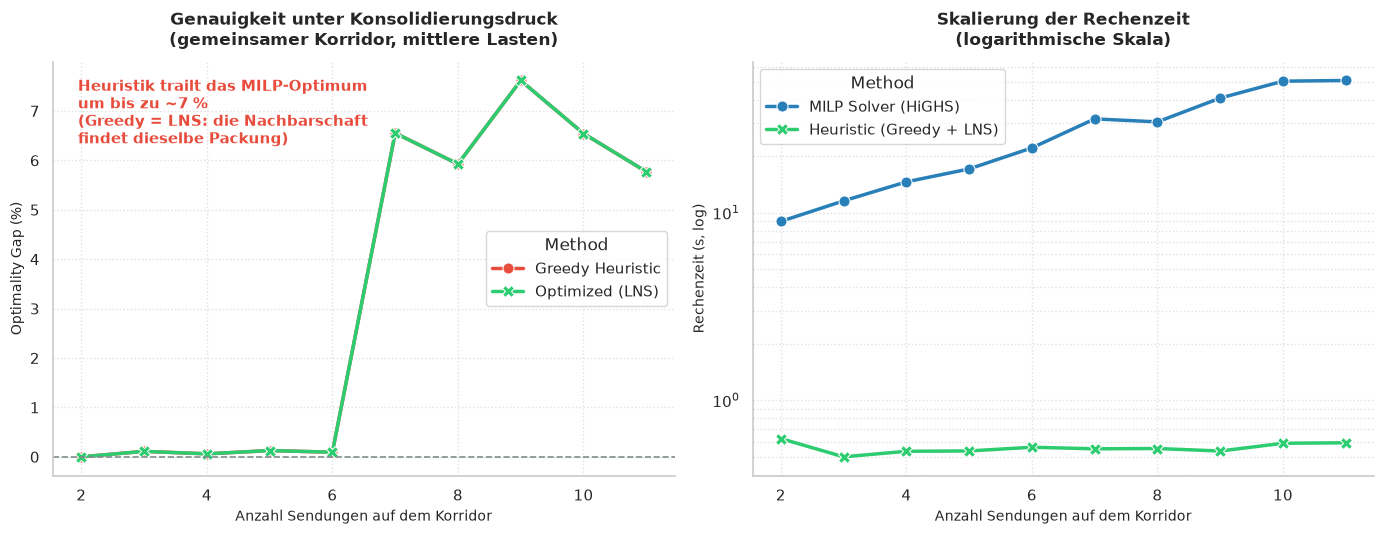

In [9]:
csizes = consol["size"]
cgreedy = [(g - m) / m * 100 for g, m in zip(consol["greedy_obj"], consol["milp_obj"])]
copt = [(o - m) / m * 100 for o, m in zip(consol["opt_obj"], consol["milp_obj"])]

cdf_gap = pd.DataFrame({
    "Number of Shipments": csizes * 2,
    "Optimality Gap (%)": cgreedy + copt,
    "Method": ["Greedy Heuristic"] * len(csizes) + ["Optimized (LNS)"] * len(csizes),
})
cdf_time = pd.DataFrame({
    "Number of Shipments": csizes * 2,
    "Runtime (s)": consol["milp_time"] + consol["opt_time"],
    "Method": ["MILP Solver (HiGHS)"] * len(csizes) + ["Heuristic (Greedy + LNS)"] * len(csizes),
})

sns.set_theme(style="whitegrid", palette="muted")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

sns.lineplot(
    data=cdf_gap, x="Number of Shipments", y="Optimality Gap (%)",
    hue="Method", style="Method", markers=True, dashes=False,
    linewidth=2.5, markersize=8, ax=ax1,
    palette={"Greedy Heuristic": "#e74c3c", "Optimized (LNS)": "#2ecc71"},
)
ax1.axhline(0, color="#7f8c8d", linestyle="--", linewidth=1.2)
ax1.set_title("Genauigkeit unter Konsolidierungsdruck\n(gemeinsamer Korridor, mittlere Lasten)",
              fontsize=12, fontweight="bold", pad=12)
ax1.set_xlabel("Anzahl Sendungen auf dem Korridor", fontsize=10)
ax1.set_ylabel("Optimality Gap (%)", fontsize=10)
ax1.grid(True, linestyle=":", alpha=0.6)
ax1.text(
    0.04, 0.96,
    "Heuristik trailt das MILP-Optimum\num bis zu ~7 %\n(Greedy = LNS: die Nachbarschaft\nfindet dieselbe Packung)",
    transform=ax1.transAxes, ha="left", va="top",
    fontsize=10.5, fontweight="bold", color="#e74c3c",
)

sns.lineplot(
    data=cdf_time, x="Number of Shipments", y="Runtime (s)",
    hue="Method", style="Method", markers=True, dashes=False,
    linewidth=2.5, markersize=8, ax=ax2,
    palette={"MILP Solver (HiGHS)": "#2980b9", "Heuristic (Greedy + LNS)": "#2ecc71"},
)
ax2.set_yscale("log")
ax2.set_title("Skalierung der Rechenzeit\n(logarithmische Skala)",
              fontsize=12, fontweight="bold", pad=12)
ax2.set_xlabel("Anzahl Sendungen auf dem Korridor", fontsize=10)
ax2.set_ylabel("Rechenzeit (s, log)", fontsize=10)
ax2.grid(True, which="both", linestyle=":", alpha=0.6)

sns.despine()
plt.tight_layout()

out_path = assets_dir / "consolidation_stress_benchmark.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Abbildung gespeichert: {out_path}")
plt.show()

## 10. Fazit: zwei Regime

- **Unabhängige Sendungen** (Abschnitt 4–7): Bei zufälligen Start-Ziel-Paaren und
  kleinen Lasten zerfällt das Problem in exakt lösbare Einzelrouten. Die Heuristik
  trifft das Optimum (Gap ≈ 0 %) bei bis zu ~140-fachem Geschwindigkeitsvorteil.
- **Konsolidierungsdruck** (Abschnitt 8–9): Müssen sich viele Sendungen dieselbe
  knappe Fahrzeugkapazität teilen, wird die optimale Bündelung zu einem
  kombinatorischen Packproblem. Hier bleibt die Heuristik messbar hinter dem
  exakten Optimum zurück (bis zu ~7 %), und die LNS-Verbesserung schließt diese
  Lücke in diesem Szenario nicht – die greedy Einfügereihenfolge dominiert das
  Ergebnis (Greedy- und LNS-Kurve fallen zusammen).

Die Heuristik ist also **kein exaktes Verfahren**: Auf typischen,
kapazitäts-unkritischen Instanzen ist sie praktisch verlustfrei, kann aber unter
starkem Konsolidierungsdruck vom MILP-Optimum abweichen. Der exakte Solver bleibt
die Referenz für Genauigkeit, die Heuristik die skalierbare Näherung.